In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv(r"C:\Users\Dell\Desktop\python DA\LengthOfStay.csv")

In [3]:
df

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,1/28/2012,3,M,0,0,0,0,0,0,...,171.422555,12.0,0.650323,30.063069,80,6.5,1,2/3/2012,B,6
99996,99997,8/6/2012,0,M,0,0,0,0,0,0,...,122.342450,12.0,1.521424,28.969548,61,6.5,1,8/7/2012,B,1
99997,99998,7/23/2012,1,M,0,0,1,0,0,0,...,108.288106,12.0,1.025677,26.354919,61,6.9,1,7/27/2012,C,4
99998,99999,12/19/2012,0,M,0,0,0,0,0,0,...,111.750731,16.0,1.035400,29.193462,59,5.6,1,12/23/2012,B,4


In [4]:
print("shape of dataset:",df.shape)
print("\nColumn names:\n", df.columns.tolist())
df.info()

shape of dataset: (100000, 28)

Column names:
 ['eid', 'vdate', 'rcount', 'gender', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'discharged', 'facid', 'lengthofstay']
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   vdate                       100000 non-null  str    
 2   rcount                      100000 non-null  str    
 3   gender                      100000 non-null  str    
 4   dialysisrenalendstage       100000 non-null  int64  
 5   asthma                      100000 non-null  int

In [5]:
print("Unique values in rcount:", df['rcount'].unique())
print("\nUnique values in gender:", df['gender'].unique())
print("\nUnique values in facid:", df['facid'].unique())
print("\nSample vdate values:", df['vdate'].head())
print("\nSample discharged values:", df['discharged'].head())

Unique values in rcount: <StringArray>
['0', '5+', '1', '3', '4', '2']
Length: 6, dtype: str

Unique values in gender: <StringArray>
['F', 'M']
Length: 2, dtype: str

Unique values in facid: <StringArray>
['B', 'A', 'E', 'D', 'C']
Length: 5, dtype: str

Sample vdate values: 0     8/29/2012
1     5/26/2012
2     9/22/2012
3      8/9/2012
4    12/20/2012
Name: vdate, dtype: str

Sample discharged values: 0      9/1/2012
1      6/2/2012
2     9/25/2012
3     8/10/2012
4    12/24/2012
Name: discharged, dtype: str


In [6]:

df['rcount'] = df['rcount'].replace('5+', '5').astype(int)


df['vdate'] = pd.to_datetime(df['vdate'])
df['discharged'] = pd.to_datetime(df['discharged'])


print(df[['rcount', 'vdate', 'discharged']].dtypes)
df[['rcount', 'vdate', 'discharged']].head()

rcount                 int64
vdate         datetime64[us]
discharged    datetime64[us]
dtype: object


,rcount,vdate,discharged
0,0,2012-08-29,2012-09-01
1,5,2012-05-26,2012-06-02
2,1,2012-09-22,2012-09-25
3,0,2012-08-09,2012-08-10
4,0,2012-12-20,2012-12-24


In [7]:

df['calculated_los'] = (df['discharged'] - df['vdate']).dt.days


print("Do they match?")
print((df['calculated_los'] == df['lengthofstay']).value_counts())


mismatches = df[df['calculated_los'] != df['lengthofstay']]
print(f"\nNumber of mismatches: {len(mismatches)}")

Do they match?
True    100000
Name: count, dtype: int64

Number of mismatches: 0


In [8]:
df.describe()

,eid,vdate,rcount,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,lengthofstay,calculated_los
count,100000.000000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000,100000.00000,100000.00000
mean,50000.500000,2012-07-02 09:42:03.744000,1.118210,0.036420,0.035270,0.094940,0.039450,0.063060,0.239040,0.051660,...,141.963384,14.097185,1.099350,29.805759,73.444720,6.493768,2.123310,2012-07-06 09:43:32.736000,4.00103,4.00103
min,1.000000,2012-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.005927,1.000000,0.219770,21.992683,21.000000,0.200000,0.000000,2012-01-02 00:00:00,1.00000,1.00000
25%,25000.750000,2012-04-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,121.682383,11.000000,0.964720,28.454235,66.000000,6.500000,1.000000,2012-04-05 00:00:00,2.00000,2.00000
50%,50000.500000,2012-07-03 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,142.088545,12.000000,1.098764,29.807516,73.000000,6.500000,1.000000,2012-07-07 00:00:00,4.00000,4.00000
75%,75000.250000,2012-10-03 00:00:00,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,162.180996,14.000000,1.234867,31.156885,81.000000,6.500000,3.000000,2012-10-06 00:00:00,6.00000,6.00000
max,100000.000000,2013-01-01 00:00:00,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,271.444277,682.500000,2.035202,38.935293,130.000000,10.000000,10.000000,2013-01-13 00:00:00,17.00000,17.00000
std,28867.657797,NaN,1.542958,0.187334,0.184462,0.293134,0.194664,0.243072,0.426499,0.221341,...,29.992996,12.952454,0.200262,2.003769,11.644555,0.568473,2.050641,NaN,2.36031,2.36031


In [9]:
if 'calclated_los' in df.columns:
    df.drop(columns=['calclated_los'], inplace=True)
    print("Dropped duplicate column")

print("Current columns:", df.columns.tolist())

Current columns: ['eid', 'vdate', 'rcount', 'gender', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'discharged', 'facid', 'lengthofstay', 'calculated_los']


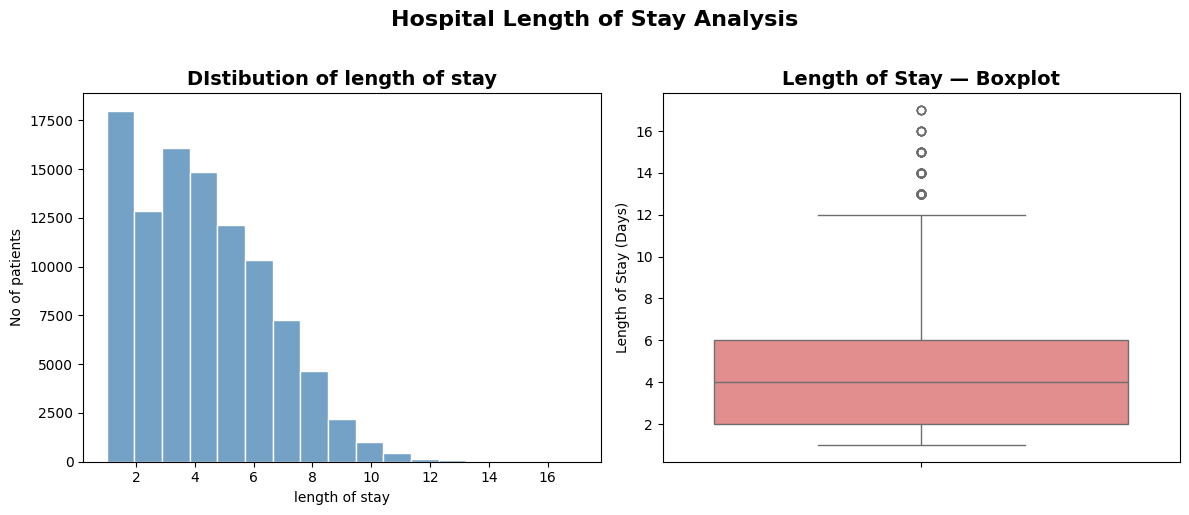

key statistics of Length of stay
Avg stay : 4.00 days
median stay : 4 days
Shortest stay    : 1 day
Longest stay     : 17 days
Patients > 7days : 8565


In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['lengthofstay'],bins=17, color='steelblue', edgecolor='white')
plt.title('DIstibution of length of stay',fontsize=14, fontweight='bold')
plt.xlabel('length of stay')
plt.ylabel('No of patients')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['lengthofstay'], color='lightcoral')
plt.title('Length of Stay — Boxplot', fontsize=14, fontweight='bold')
plt.ylabel('Length of Stay (Days)')

plt.suptitle('Hospital Length of Stay Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('key statistics of Length of stay')
print(f'Avg stay : {df['lengthofstay'].mean():.2f} days')
print(f'median stay : {df['lengthofstay'].median():.0f} days')
print(f"Shortest stay    : {df['lengthofstay'].min():.0f} day")
print(f"Longest stay     : {df['lengthofstay'].max():.0f} days")
print(f"Patients > 7days : {(df['lengthofstay'] > 7).sum()}")

Average Length of Stay per Facility:
facid
A    3.27
B    3.28
C    4.89
D    4.83
E    5.16
Name: lengthofstay, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_4104\311639745.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_los.index, y=avg_los.values, palette='Set2')


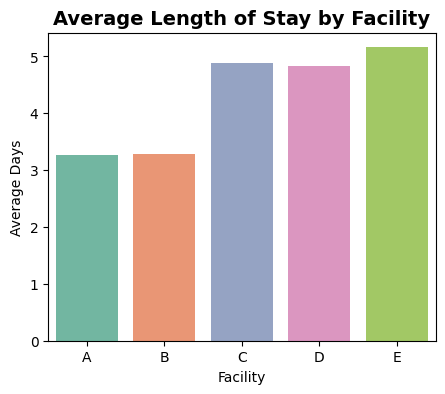

In [11]:

avg_los = df.groupby('facid')['lengthofstay'].mean().round(2)
print("Average Length of Stay per Facility:")
print(avg_los)

plt.figure(figsize=(5,4))
sns.barplot(x=avg_los.index, y=avg_los.values, palette='Set2')
plt.title('Average Length of Stay by Facility', fontsize=14, fontweight='bold')
plt.xlabel('Facility')
plt.ylabel('Average Days')
plt.show()

Patient Count per Facility:
facid
A    30035
B    30012
C     4699
D     4499
E    30755
Name: eid, dtype: int64


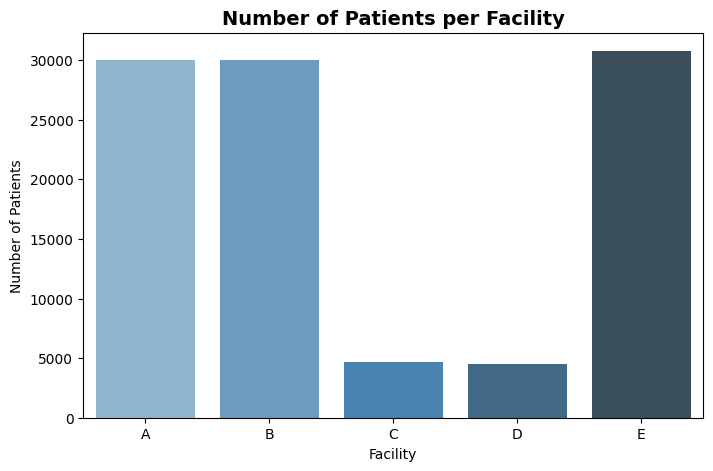

In [12]:

patient_count = df.groupby('facid')['eid'].count()
print("Patient Count per Facility:")
print(patient_count)

plt.figure(figsize=(8, 5))
sns.barplot(x=patient_count.index, y=patient_count.values,
            hue=patient_count.index, legend=False, palette='Blues_d')
plt.title('Number of Patients per Facility', fontsize=14, fontweight='bold')
plt.xlabel('Facility')
plt.ylabel('Number of Patients')
plt.show()

Average LOS by Readmission Count:
rcount
0    2.72
1    3.70
2    5.27
3    6.27
4    7.26
5    8.29
Name: lengthofstay, dtype: float64


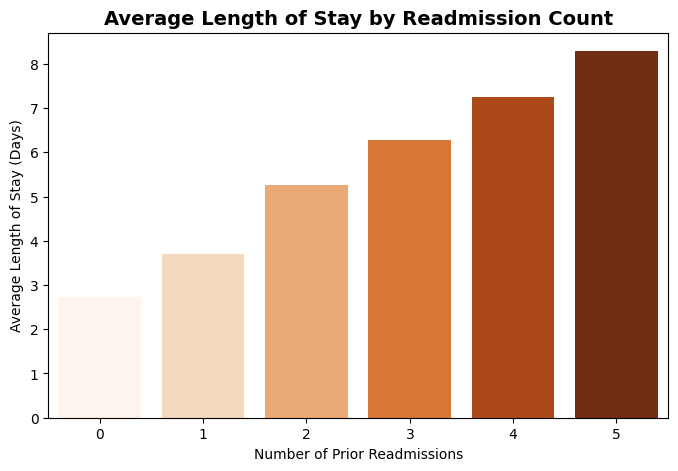

In [13]:

avg_los_rcount = df.groupby('rcount')['lengthofstay'].mean().round(2)
print("Average LOS by Readmission Count:")
print(avg_los_rcount)

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_los_rcount.reset_index(),
            x='rcount', y='lengthofstay',
            hue='rcount', legend=False, palette='Oranges')
plt.title('Average Length of Stay by Readmission Count',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Prior Readmissions')
plt.ylabel('Average Length of Stay (Days)')
plt.show()

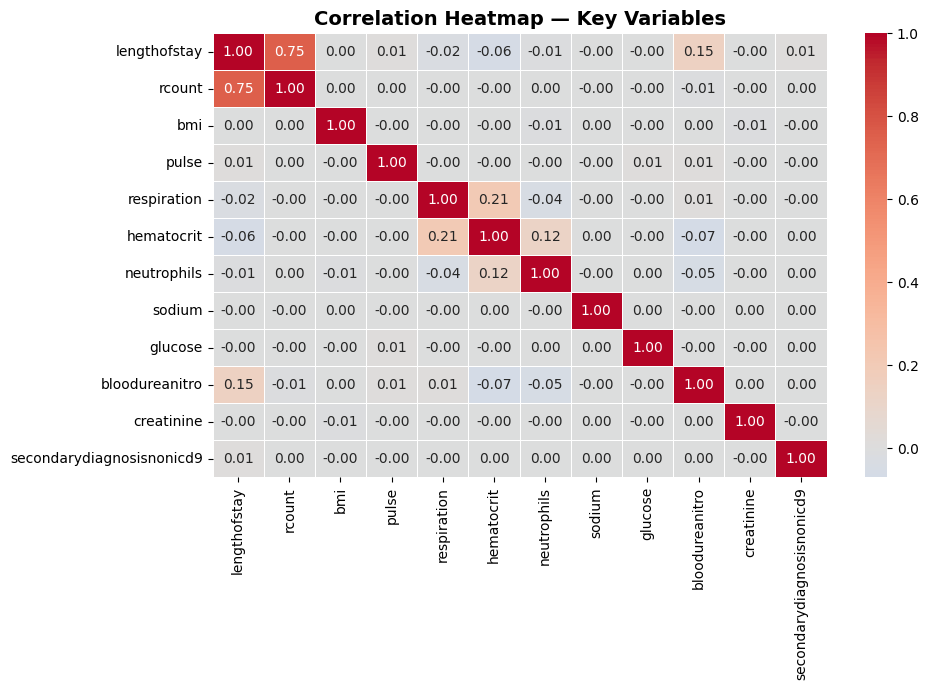

In [14]:

numeric_cols = ['lengthofstay', 'rcount', 'bmi', 'pulse', 
                'respiration', 'hematocrit', 'neutrophils',
                'sodium', 'glucose', 'bloodureanitro', 
                'creatinine', 'secondarydiagnosisnonicd9']

corr_matrix = df[numeric_cols].corr().round(2)

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, 
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5)
plt.title('Correlation Heatmap — Key Variables', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:

df['high_risk'] = (
    (df['rcount'] >= 3) &          
    (df['lengthofstay'] >= 7) &    
    (df['bloodureanitro'] > 20)    )


high_risk_count = df['high_risk'].sum()
total_patients = len(df)
high_risk_pct = (high_risk_count / total_patients * 100).round(2)

print("=" * 55)
print("   HOSPITAL BED UTILIZATION — KEY FINDINGS SUMMARY")
print("=" * 55)

print(f"\n DATASET OVERVIEW")
print(f"   Total patients analyzed : {total_patients:,}")
print(f"   Total facilities        : {df['facid'].nunique()}")
print(f"   Date range              : {df['vdate'].min().date()} to {df['vdate'].max().date()}")

print(f"\n LENGTH OF STAY INSIGHTS")
print(f"   Average stay            : {df['lengthofstay'].mean():.2f} days")
print(f"   Median stay             : {df['lengthofstay'].median():.0f} days")
print(f"   Longest stay            : {df['lengthofstay'].max():.0f} days")
print(f"   Patients staying 7+days : {(df['lengthofstay'] >= 7).sum():,} ({(df['lengthofstay'] >= 7).mean()*100:.1f}%)")

print(f"\n FACILITY INSIGHTS")
facility_avg = df.groupby('facid')['lengthofstay'].mean().round(2)
for fac, avg in facility_avg.items():
    print(f"   Facility {fac}             : {avg} days avg stay")

print(f"\n READMISSION INSIGHTS")
print(f"   Avg LOS — 0 readmissions: {df[df['rcount']==0]['lengthofstay'].mean():.2f} days")
print(f"   Avg LOS — 5 readmissions: {df[df['rcount']==5]['lengthofstay'].mean():.2f} days")
print(f"   LOS increase per readmit: ~{((df[df['rcount']==5]['lengthofstay'].mean() - df[df['rcount']==0]['lengthofstay'].mean()) / 5):.2f} days")

print(f"\n HIGH RISK PATIENTS")
print(f"   Criteria: 3+ readmissions AND 7+ day stay AND elevated BUN")
print(f"   High risk count         : {high_risk_count:,}")
print(f"   % of total patients     : {high_risk_pct}%")

print(f"\n HIGH RISK BY FACILITY")
high_risk_by_facility = df[df['high_risk']].groupby('facid')['eid'].count()
for fac, count in high_risk_by_facility.items():
    print(f"   Facility {fac}             : {count} high risk patients")

print("\n" + "=" * 55)
print("   RECOMMENDATIONS")
print("=" * 55)
print("""
1. READMISSION PREVENTION
   Patients with 3+ readmissions stay 3x longer.
   Invest in post-discharge follow-up programs
   to reduce repeat admissions.

2. FACILITY E CAPACITY PLANNING
   Highest patient volume + longest avg stay.
   Review staffing and bed allocation for Facility E.

3. FACILITIES C & D SPECIALIZATION
   Low volume but long stays suggest complex cases.
   Ensure adequate specialist availability.

4. HIGH RISK PATIENT PATHWAY
   Flag patients with 3+ readmissions on admission
   for early intervention and discharge planning.
""")

   HOSPITAL BED UTILIZATION — KEY FINDINGS SUMMARY

 DATASET OVERVIEW
   Total patients analyzed : 100,000
   Total facilities        : 5
   Date range              : 2012-01-01 to 2013-01-01

 LENGTH OF STAY INSIGHTS
   Average stay            : 4.00 days
   Median stay             : 4 days
   Longest stay            : 17 days
   Patients staying 7+days : 15,828 (15.8%)

 FACILITY INSIGHTS
   Facility A             : 3.27 days avg stay
   Facility B             : 3.28 days avg stay
   Facility C             : 4.89 days avg stay
   Facility D             : 4.83 days avg stay
   Facility E             : 5.16 days avg stay

 READMISSION INSIGHTS
   Avg LOS — 0 readmissions: 2.72 days
   Avg LOS — 5 readmissions: 8.29 days
   LOS increase per readmit: ~1.11 days

 HIGH RISK PATIENTS
   Criteria: 3+ readmissions AND 7+ day stay AND elevated BUN
   High risk count         : 1,681
   % of total patients     : 1.68%

 HIGH RISK BY FACILITY
   Facility A             : 153 high risk patients
  